In [1]:
print("hello")

hello


In [2]:
import os
from pathlib import Path
from dotenv import load_dotenv 

In [3]:
BASE_PATH = Path().resolve()

In [4]:
images_root = BASE_PATH/"images"

In [5]:
str(images_root/"animal"/"cat.jpg")

'/Users/madhushivagangaks/Desktop/Projects/sementic-image-search/semantic_image_search/notebooks/images/animal/cat.jpg'

In [6]:
load_dotenv()

True

In [7]:
from langchain_experimental.open_clip import OpenCLIPEmbeddings

In [8]:
embedding = OpenCLIPEmbeddings(
    model_name="ViT-B-32",
    checkpoint="laion2b_s34b_b79k", 
    device="cpu"
)

/Users/madhushivagangaks/Desktop/Projects/sementic-image-search/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
img_embedding = embedding.embed_image([str(images_root/"animal"/"cat.jpeg")])

In [10]:
img_embedding

[[0.04853687435388565,
  -0.0014370474964380264,
  -0.03448856994509697,
  -0.08087967336177826,
  0.026776505634188652,
  0.07083477824926376,
  -0.00827895849943161,
  -0.048146698623895645,
  0.058699529618024826,
  0.014000637456774712,
  0.018617749214172363,
  -0.026211177930235863,
  -0.02443608269095421,
  -0.056170035153627396,
  -0.013328194618225098,
  0.02580808848142624,
  -0.12121999263763428,
  -0.021169696003198624,
  -0.010361786000430584,
  0.0012651474680751562,
  0.015890365466475487,
  -0.010824793018400669,
  -0.047347504645586014,
  -0.011073386296629906,
  -0.06817597895860672,
  -0.025547251105308533,
  -0.05428945645689964,
  0.016541993245482445,
  -0.02675354667007923,
  -0.016311421990394592,
  -0.028907617554068565,
  -0.010116634890437126,
  -0.050070732831954956,
  0.03665084391832352,
  -0.051859982311725616,
  -0.0010905874660238624,
  0.003515122691169381,
  0.08354654163122177,
  -0.07093161344528198,
  -0.06484896689653397,
  0.06235942989587784,
  

In [11]:
len(img_embedding[0])

512

In [12]:
url=os.environ["QDRANT_URL"]

In [13]:
api_key=os.environ["QDRANT_API_KEY"]

In [14]:
from qdrant_client import QdrantClient

In [15]:
qdrant_client = QdrantClient(url=url, api_key=api_key)

In [16]:
qdrant_client.get_collections()

CollectionsResponse(collections=[CollectionDescription(name='sematic-image-search')])

In [17]:
collections = qdrant_client.get_collections().collections

In [18]:
collections

[CollectionDescription(name='sematic-image-search')]

In [19]:
COLLECTION_NAME = "sematic-image-search"
VECTOR_SIZE = 512 

In [20]:
from qdrant_client.http import models

In [21]:
qdrant_client.create_collection(
    collection_name=COLLECTION_NAME,
    vectors_config=models.VectorParams(
        size=VECTOR_SIZE,
        distance=models.Distance.COSINE,
    )
)

UnexpectedResponse: Unexpected Response: 409 (Conflict)
Raw response content:
b'{"status":{"error":"Wrong input: Collection `sematic-image-search` already exists!"},"time":0.040579386}'

In [22]:
qdrant_client.get_collections()

CollectionsResponse(collections=[CollectionDescription(name='sematic-image-search')])

In [23]:
collections = qdrant_client.get_collections().collections
existing_names = {c.name for c in collections}

In [24]:
existing_names

{'sematic-image-search'}

In [25]:
if COLLECTION_NAME not in existing_names:
    print(f"Creating collection: {COLLECTION_NAME}")
    qdrant_client.create_collection(
        collection_name=COLLECTION_NAME,
        vectors_config=models.VectorParams(
            size=VECTOR_SIZE,
            distance=models.Distance.COSINE,
        ),
    )
else:
    print(f"Collection already exists: {COLLECTION_NAME} (reusing)")

Collection already exists: sematic-image-search (reusing)


In [26]:
import numpy as np
from PIL import Image
from uuid import uuid4

In [27]:
def index_image(image_path,category=None):
    img_embed=embedding.embed_image([image_path])[0]
    emb=np.array(img_embed).tolist()
    
    payload = {
        "filename": os.path.basename(image_path),
        "path":image_path,
        "category": category
    }
    
    qdrant_client.upsert(
        collection_name=COLLECTION_NAME,
        points=[
            models.PointStruct(
                id=str(uuid4()),
                vector=emb,
                payload=payload
            )
        ]
    )
    print(f"Indexed → {image_path}")

In [28]:
cat_image_path=str(images_root/"animal"/"cat.jpeg")

In [29]:
payload = {
    "filename": 'cat.jpeg',
    "path":'/Users/madhushivagangaks/Desktop/Projects/sementic-image-search/semantic_image_search/notebooks/images/animal/cat.jpeg',
    "category": 'animal'
}

In [41]:
index_image(cat_image_path,category="animal")

Indexed → /Users/madhushivagangaks/Desktop/Projects/sementic-image-search/semantic_image_search/notebooks/images/animal/cat.jpeg


In [42]:
def index_folder(root_folder):
    exts = (".jpg", ".jpeg", ".png", ".webp")
    for dirpath, _, files in os.walk(root_folder):
        category = os.path.basename(dirpath)
        for f in files:
            if f.lower().endswith(exts):
                img_path = os.path.join(dirpath, f)
                #print(img_path,category)
                index_image(img_path,category=category)

In [43]:
index_folder("images")

Indexed → images/weapon/pistol.jpeg
Indexed → images/weapon/ak47.jpeg
Indexed → images/weapon/crocodile_1.png
Indexed → images/general/bottle.jpeg
Indexed → images/general/chair.jpeg
Indexed → images/general/laptop.jpeg
Indexed → images/general/cycle.webp
Indexed → images/general/phone.jpeg
Indexed → images/general/pen.webp
Indexed → images/general/table.jpeg
Indexed → images/general/car.webp
Indexed → images/flower/tulip.webp
Indexed → images/flower/rose.jpg
Indexed → images/flower/sunflower.jpeg
Indexed → images/flower/lavender.jpeg
Indexed → images/flower/marigold.jpeg
Indexed → images/flower/lotus.jpg
Indexed → images/flower/lily.jpeg
Indexed → images/furniture/table.jpeg
Indexed → images/uncategorized/lion.jpeg
Indexed → images/uncategorized/ak47.jpeg
Indexed → images/uncategorized/crocodile_1.png
Indexed → images/uncategorized/sam_altman.jpeg
Indexed → images/animal/cat.jpeg
Indexed → images/animal/zebra.jpeg
Indexed → images/animal/horse.webp
Indexed → images/animal/giraffe.webp

### Retrieval operation Text --> Image retrievel

In [30]:
def search_text(query,k=5):
    results = qdrant_client.query_points(
        collection_name=COLLECTION_NAME,
        query=query,
        limit=k,
        with_payload=True,
        with_vectors=True
    )
    return results

In [31]:
query = "give me a human image"

In [32]:
results = search_text(embedding.embed_query(query),k=3)

In [33]:
for point in results.points:
    print(point.payload, "score =", point.score)

{'filename': 'cat.jpeg', 'path': 'images/animal/cat.jpeg', 'category': 'animal'} score = 0.18396875
{'filename': 'cat.jpeg', 'path': '/Users/madhushivagangaks/Desktop/Projects/sementic-image-search/semantic_image_search/notebooks/images/animal/cat.jpeg', 'category': 'animal'} score = 0.18396875
{'filename': 'lion.jpeg', 'path': 'images/uncategorized/lion.jpeg', 'category': 'uncategorized'} score = 0.17745796


In [34]:
for point in results.points:
    print("Payload:", point.payload)
    # print("Vector:", point.vector)
    print("Score:", point.score)

Payload: {'filename': 'cat.jpeg', 'path': 'images/animal/cat.jpeg', 'category': 'animal'}
Score: 0.18396875
Payload: {'filename': 'cat.jpeg', 'path': '/Users/madhushivagangaks/Desktop/Projects/sementic-image-search/semantic_image_search/notebooks/images/animal/cat.jpeg', 'category': 'animal'}
Score: 0.18396875
Payload: {'filename': 'lion.jpeg', 'path': 'images/uncategorized/lion.jpeg', 'category': 'uncategorized'}
Score: 0.17745796


In [35]:
def search_by_image(image_path,k=5):
    emb = embedding.embed_image([image_path])[0]
    results = qdrant_client.query_points(
        collection_name=COLLECTION_NAME,
        query=emb,
        limit=k,
        with_payload=True
    )
    return results

In [36]:
query_image = cat_image_path

In [37]:
results= search_by_image(query_image,k=3)

In [38]:
for point in results.points:
    print(point.payload, "score =", point.score)

{'filename': 'cat.jpeg', 'path': 'images/animal/cat.jpeg', 'category': 'animal'} score = 1.0000001
{'filename': 'cat.jpeg', 'path': '/Users/madhushivagangaks/Desktop/Projects/sementic-image-search/semantic_image_search/notebooks/images/animal/cat.jpeg', 'category': 'animal'} score = 1.0000001
{'filename': 'tiger.jpeg', 'path': 'images/animal/tiger.jpeg', 'category': 'animal'} score = 0.6035044


In [39]:
import os
from PIL import Image
from pathlib import Path
import shutil
import uuid

def save_retrieved_images(results, output_dir="retrieved_results"):
    output_dir = Path(output_dir) / uuid.uuid4().hex
    output_dir.mkdir(parents=True, exist_ok=True)

    for idx, point in enumerate(results.points):
        try:
            img_path = point.payload["path"]
            img = Image.open(img_path)

            save_path = output_dir / f"result_{idx}.png"
            img.save(save_path)

        except Exception as e:
            print(f"Error saving image {idx}: {e}")

    print(f"Images saved in → {output_dir}")
    return str(output_dir)

In [40]:
folder = save_retrieved_images(results)

Images saved in → retrieved_results/278769d349f44c53a98b5ab008a6eb37


In [41]:
from IPython.display import display

def display_retrieved_images(results):
    for point in results.points:
        try:
            img_path = point.payload["path"]
            print("Showing →", img_path)
            display(Image.open(img_path))
        except Exception as e:
            print(f"Error displaying image: {e}")

Showing → images/animal/cat.jpeg


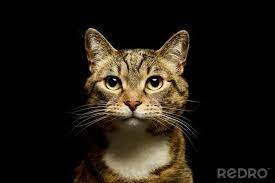

Showing → /Users/madhushivagangaks/Desktop/Projects/sementic-image-search/semantic_image_search/notebooks/images/animal/cat.jpeg


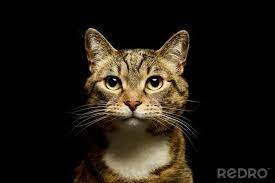

Showing → images/animal/tiger.jpeg


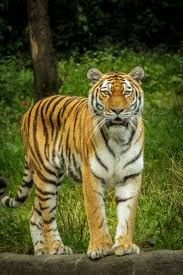

In [42]:
display_retrieved_images(results)

In [43]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder, PromptTemplate
from langchain_openai import ChatOpenAI

In [44]:
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)

OpenAIError: Missing credentials. Please pass an `api_key`, `workload_identity`, `admin_api_key`, or set the `OPENAI_API_KEY` or `OPENAI_ADMIN_KEY` environment variable.

In [ ]:
llm.invoke("hi")

In [45]:
TRANSLATOR_PROMPT = """
You are an expert at rewriting queries for the CLIP image–text model.

Goal:
Rewrite the user query into a short, concrete, descriptive image caption.
The rewritten query must maximize CLIP retrieval accuracy.

Guidelines:
- Keep the original meaning.
- Use 3–12 word caption style.
- Remove chat words (show me, give me, please, etc.)
- Keep colors, objects, actions.
- Translate to English if needed.
- Do NOT add new details.

User Query: {input_query}

Respond with only the rewritten caption.
"""

In [46]:
translator_prompt = PromptTemplate(
    input_variables=["input_query"],
    template=TRANSLATOR_PROMPT,
)

In [47]:
def translate_query(user_query):
    prompt = translator_prompt.format(input_query=user_query)
    response = llm.invoke(prompt)
    return response.content.strip()

In [49]:
raw_query = "Show me a picture of a very active crocodile in the water"

In [50]:
translated = translate_query(raw_query)

NameError: name 'llm' is not defined

In [ ]:
translated = translate_query(raw_query)
vector = embedding.embed_query(translated)
results = search_text(vector, k=3)


In [ ]:
display_retrieved_images(results)